In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import time
#import gget
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from tqdm import tqdm
import textwrap

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
import cuml

sc.settings.verbosity = 3

# Ng Data

# Load anndata

In [2]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/fib_ihsc_processed.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 650 ms, sys: 2 s, total: 2.65 s
Wall time: 9.2 s


AnnData object with n_obs × n_vars = 15317 × 23434
    obs: 'batch', 'barcoded_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'cluster'
    var: 'gene_id', 'gene_type', 'Chromosome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'batch_colors', 'cluster_colors', 'dr

# Load Capybara scores

In [3]:
%%time
# Load Capybara output
fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/ng_scale.csv"
df = pd.read_csv(fpath_scale)
print(f"{df.shape=}")
df.head()

df.shape=(15317, 13)
CPU times: user 43.2 ms, sys: 6.57 ms, total: 49.8 ms
Wall time: 111 ms


,cell_name,frxn_Endothelial,frxn_Erythroid/Mega,frxn_Gran/Mono,frxn_HSPC1,frxn_HSPC2,frxn_HSPC3,frxn_Hemogenic_endothelium,frxn_Myeloid,frxn_Stroma,frxn_Vessel_endothelium,Lagrangian,Error
0,AAACCCAAGGTTACCT-1_hsc,-2.823987e-18,0.090617,3.256123e-02,-1.438486e-18,1.387779e-17,0.000000e+00,-2.305926e-17,5.689187e-18,0.188664,0.412287,0,2014.549285
1,AAACCCAAGTTGAAGT-1_hsc,-5.190018e-18,0.089798,0.000000e+00,-4.714086e-17,2.919871e-18,-1.110223e-16,-4.039689e-17,-4.249726e-17,0.088374,0.479904,0,2103.894539
2,AAACCCAAGTTGTCGT-1_hsc,2.357400e-01,0.093449,0.000000e+00,2.225399e-18,1.061438e-01,2.933539e-17,-2.070477e-17,1.473682e-17,0.275265,0.005473,0,2008.296269
3,AAACCCACAGAAGCGT-1_hsc,0.000000e+00,0.002729,1.426238e-02,5.444226e-17,1.708621e-19,0.000000e+00,8.639065e-18,2.823520e-17,0.292336,0.392263,0,2044.668134
4,AAACCCACAGGAGGTT-1_hsc,0.000000e+00,0.146379,1.387779e-17,-2.420428e-18,3.178302e-20,1.305302e-17,-1.462469e-17,0.000000e+00,0.044108,0.549775,0,1889.091148


In [4]:
# Set index to 'cell_name' for merging
df = df.set_index('cell_name')

# Sanity check: ensure all indices in df exist in adata.obs
common_cells = adata.obs.index.intersection(df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
adata.obs = adata.obs.join(df, how='left')  # 'left' keeps all cells in adata.obs

adata.obs.head()

Merging on 15317 shared cells


,batch,barcoded_phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,frxn_Gran/Mono,frxn_HSPC1,frxn_HSPC2,frxn_HSPC3,frxn_Hemogenic_endothelium,frxn_Myeloid,frxn_Stroma,frxn_Vessel_endothelium,Lagrangian,Error
AAACCCAAGGTTACCT-1_hsc,hsc,unknown,3700,8.216358,11235.0,9.326878,27.850467,37.641300,47.396529,60.293725,...,3.256123e-02,-1.438486e-18,1.387779e-17,0.000000e+00,-2.305926e-17,5.689187e-18,0.188664,0.412287,0,2014.549285
AAACCCAAGTTGAAGT-1_hsc,hsc,unknown,4024,8.300280,10634.0,9.271906,24.637954,32.697010,40.671431,53.112658,...,0.000000e+00,-4.714086e-17,2.919871e-18,-1.110223e-16,-4.039689e-17,-4.249726e-17,0.088374,0.479904,0,2103.894539
AAACCCAAGTTGTCGT-1_hsc,hsc,unknown,2593,7.860956,6743.0,8.816408,28.503633,37.327599,48.079490,63.458401,...,0.000000e+00,2.225399e-18,1.061438e-01,2.933539e-17,-2.070477e-17,1.473682e-17,0.275265,0.005473,0,2008.296269
AAACCCACAGAAGCGT-1_hsc,hsc,unknown,2371,7.771489,5430.0,8.599879,24.622468,34.696133,45.101289,60.515654,...,1.426238e-02,5.444226e-17,1.708621e-19,0.000000e+00,8.639065e-18,2.823520e-17,0.292336,0.392263,0,2044.668134
AAACCCACAGGAGGTT-1_hsc,hsc,unknown,5037,8.524764,22012.0,9.999388,31.737234,40.414319,50.000000,63.310921,...,1.387779e-17,-2.420428e-18,3.178302e-20,1.305302e-17,-1.462469e-17,0.000000e+00,0.044108,0.549775,0,1889.091148


In [5]:
adata = adata[~adata.obs["cluster"].isin(["C4", "C5"])].copy()

# Optional sanity check
adata.obs["cluster"].value_counts()

cluster
R2    4343
R1    1986
R3     524
Name: count, dtype: int64

# Predictions by Cluster

In [6]:
cluster_palette = {
    "R1": "#FCAE91",
    "R2": "#FB6A4A",
    "R3": "#CB181D",
}

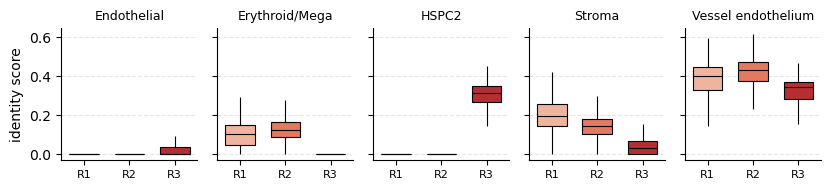

In [7]:
# Copy and melt
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

df_melted = df_melted[
    df_melted["Cell Type"].isin([
        "frxn_Endothelial",
        "frxn_Erythroid/Mega",
        "frxn_HSPC2",
        "frxn_Stroma",
        "frxn_Vessel_endothelium"
    ])
]

# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    hue="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.85,
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue="cluster",                # <-- color by cluster
    order=sorted(df["cluster"].unique()),
    palette=cluster_palette,      # <-- custom colors
    width=0.65,
    linecolor="k",
    capprops={"linewidth": 0},
    showfliers=False,
    linewidth=0.8,
    dodge=False
)# <-- keep boxes centered


g.set_axis_labels("", "identity score")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
     
    title = ax.get_title()
    title = title.split("frxn_")[1]
    if len(title) > 20:
        title = "\n".join(title.split(maxsplit=1))
    title = title.replace("_", " ")
    ax.set_title(title, fontsize=9)

g.fig.subplots_adjust(wspace=0.2)

plt.tight_layout()
plt.show()

## Gomes Data

In [3]:
%%time
# Load Capybara output
fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/gomes_scale.csv"
df = pd.read_csv(fpath_scale)
print(f"{df.shape=}")
df.head()

df.shape=(15317, 8)
CPU times: user 19.1 ms, sys: 6.52 ms, total: 25.7 ms
Wall time: 144 ms


,cell_name,frxn_DAY2,frxn_DAY15,frxn_DAY25,frxn_HDF,frxn_UCB,Lagrangian,Error
0,AAACCCAAGGTTACCT-1_hsc,0.173329,1.097750e-01,0.261041,0.081183,0.113204,0,2084.412396
1,AAACCCAAGTTGAAGT-1_hsc,0.225308,-3.469447e-18,0.298980,0.039602,0.138219,0,2146.681747
2,AAACCCAAGTTGTCGT-1_hsc,0.000000,2.247813e-01,0.023023,0.295675,0.108229,0,2197.450949
3,AAACCCACAGAAGCGT-1_hsc,0.044909,1.318804e-01,0.061457,0.393486,0.067064,0,2160.707842
4,AAACCCACAGGAGGTT-1_hsc,0.280210,2.172434e-01,0.180802,0.003249,0.056419,0,1958.209402


In [4]:
# Set index to 'cell_name' for merging
df = df.set_index('cell_name')

# Sanity check: ensure all indices in df exist in adata.obs
common_cells = adata.obs.index.intersection(df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
adata.obs = adata.obs.join(df, how='left')  # 'left' keeps all cells in adata.obs

adata.obs.head()

Merging on 15317 shared cells


,batch,barcoded_phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,leiden,cluster_str,cluster,frxn_DAY2,frxn_DAY15,frxn_DAY25,frxn_HDF,frxn_UCB,Lagrangian,Error
AAACCCAAGGTTACCT-1_hsc,hsc,unknown,3700,8.216358,11235.0,9.326878,27.850467,37.641300,47.396529,60.293725,...,0,C1,R2,0.173329,1.097750e-01,0.261041,0.081183,0.113204,0,2084.412396
AAACCCAAGTTGAAGT-1_hsc,hsc,unknown,4024,8.300280,10634.0,9.271906,24.637954,32.697010,40.671431,53.112658,...,0,C1,R2,0.225308,-3.469447e-18,0.298980,0.039602,0.138219,0,2146.681747
AAACCCAAGTTGTCGT-1_hsc,hsc,unknown,2593,7.860956,6743.0,8.816408,28.503633,37.327599,48.079490,63.458401,...,2,C3,C5,0.000000,2.247813e-01,0.023023,0.295675,0.108229,0,2197.450949
AAACCCACAGAAGCGT-1_hsc,hsc,unknown,2371,7.771489,5430.0,8.599879,24.622468,34.696133,45.101289,60.515654,...,3,C4,C4,0.044909,1.318804e-01,0.061457,0.393486,0.067064,0,2160.707842
AAACCCACAGGAGGTT-1_hsc,hsc,unknown,5037,8.524764,22012.0,9.999388,31.737234,40.414319,50.000000,63.310921,...,0,C1,R2,0.280210,2.172434e-01,0.180802,0.003249,0.056419,0,1958.209402


In [5]:
adata = adata[~adata.obs["cluster"].isin(["C4", "C5"])].copy()

# Optional sanity check
adata.obs["cluster"].value_counts()

cluster
R2    4343
R1    1986
R3     524
Name: count, dtype: int64

# Predictions by Cluster

In [9]:
cluster_palette = {
    "R1": "#FCAE91",
    "R2": "#FB6A4A",
    "R3": "#CB181D",
}

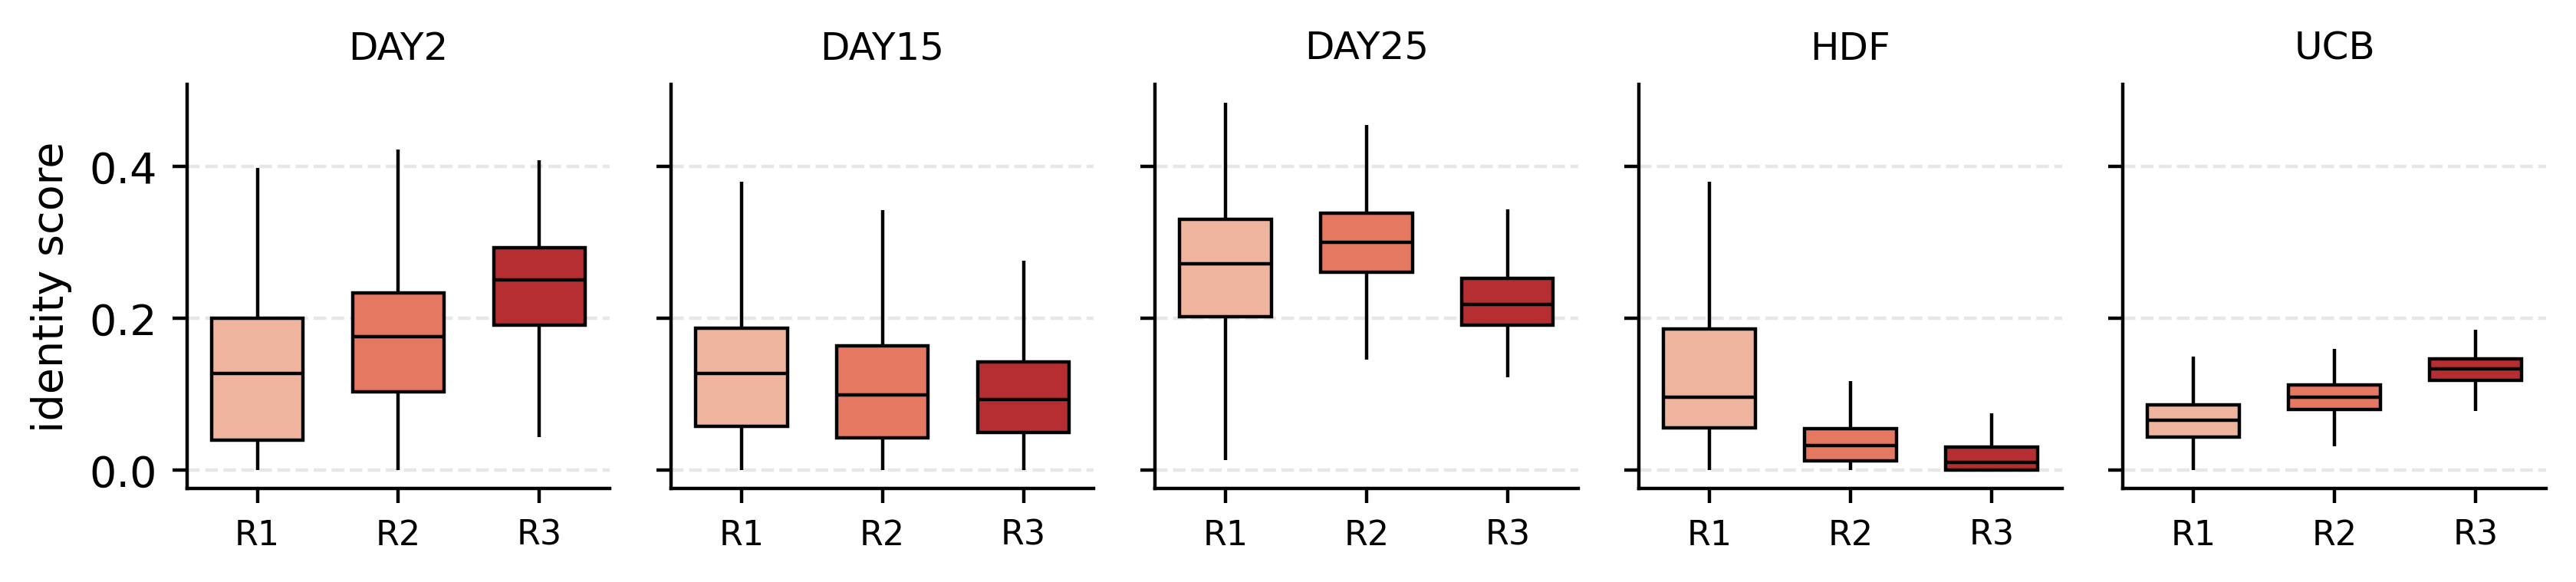

In [21]:
# Copy and melt
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)
#df_melted = df_melted[df_melted["Cell Type"] == "frxn_DAY25"]


# Plot with FacetGrid
g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    hue="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.85,
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue="cluster",                # <-- color by cluster
    order=sorted(df["cluster"].unique()),
    palette=cluster_palette,      # <-- custom colors
    width=0.65,
    linecolor="k",
    capprops={"linewidth": 0},
    showfliers=False,
    linewidth=0.8,
    dodge=False                   # <-- keep boxes centered
)

g.set_axis_labels("", "identity score")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
     
    title = ax.get_title()
    title = title.split("frxn_")[1]
    if len(title) > 20:
        title = "\n".join(title.split(maxsplit=1))
    ax.set_title(title, fontsize=9)

g.fig.subplots_adjust(wspace=0.2)
plt.rcParams["figure.dpi"] = 400
plt.tight_layout()
plt.show()


# Reference Atlas Data

# Load anndata

In [2]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/fib_ihsc_processed.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 562 ms, sys: 1.74 s, total: 2.3 s
Wall time: 7.4 s


AnnData object with n_obs × n_vars = 15317 × 23434
    obs: 'batch', 'barcoded_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'cluster'
    var: 'gene_id', 'gene_type', 'Chromosome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'batch_colors', 'cluster_colors', 'dr

# Load Capybara scores

In [3]:
%%time
fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/celltype_simplified_scale.csv"
df = pd.read_csv(fpath_scale)
print(f"{df.shape=}")
df.head()

df.shape=(15317, 18)
CPU times: user 46.3 ms, sys: 10.2 ms, total: 56.5 ms
Wall time: 110 ms


,cell_name,frxn_blood vessel endothelial cell,frxn_embryonic fibroblast,frxn_endothelial cell,frxn_endothelial cell of vascular tree,frxn_erythroid progenitor cell,frxn_fibro/adipogenic progenitor cell,frxn_fibroblast,frxn_hematopoietic multipotent progenitor cell,frxn_hematopoietic precursor cell,frxn_hematopoietic stem cell,frxn_megakaryocyte progenitor cell,frxn_retinal blood vessel endothelial cell,frxn_skeletal muscle fibroblast,frxn_skin fibroblast,frxn_vein endothelial cell,Lagrangian,Error
0,AAACCCAAGGTTACCT-1_hsc,0.032133,0.217016,0.089362,-1.502227e-18,0.142176,0.211293,-7.571988e-17,-2.317283e-17,6.267965e-02,3.516860e-02,-1.348299e-18,1.033704e-02,0.000000e+00,0.112415,-8.190032e-17,0,2332.512327
1,AAACCCAAGTTGAAGT-1_hsc,0.004663,0.167316,0.070082,-1.412583e-18,0.162263,0.306671,-8.641335e-17,-1.959392e-17,4.629240e-02,2.062320e-02,-6.473278e-19,8.433139e-02,0.000000e+00,0.043523,-4.114227e-17,0,2404.627863
2,AAACCCAAGTTGTCGT-1_hsc,0.042700,0.289247,0.006550,0.000000e+00,0.242192,0.140104,-1.140371e-17,1.273411e-17,2.055963e-02,3.061325e-17,8.214491e-18,2.372263e-18,-1.646951e-19,0.108224,1.825718e-17,0,2371.801089
3,AAACCCACAGAAGCGT-1_hsc,0.001366,0.242185,0.021702,-2.510081e-19,0.092797,0.192374,-1.993481e-18,-1.591642e-17,6.497617e-02,4.913225e-19,3.551646e-19,4.893641e-02,0.000000e+00,0.202499,1.916034e-17,0,2418.659557
4,AAACCCACAGGAGGTT-1_hsc,0.040214,0.223023,0.164420,9.392213e-19,0.178626,0.129039,-2.162870e-18,-5.825019e-17,-1.291351e-17,0.000000e+00,-4.825440e-18,3.703020e-02,-2.434538e-19,0.104846,3.773079e-17,0,2155.126194


In [4]:
list(df.columns)

['cell_name',
 'frxn_blood vessel endothelial cell',
 'frxn_embryonic fibroblast',
 'frxn_endothelial cell',
 'frxn_endothelial cell of vascular tree',
 'frxn_erythroid progenitor cell',
 'frxn_fibro/adipogenic progenitor cell',
 'frxn_fibroblast',
 'frxn_hematopoietic multipotent progenitor cell',
 'frxn_hematopoietic precursor cell',
 'frxn_hematopoietic stem cell',
 'frxn_megakaryocyte progenitor cell',
 'frxn_retinal blood vessel endothelial cell',
 'frxn_skeletal muscle fibroblast',
 'frxn_skin fibroblast',
 'frxn_vein endothelial cell',
 'Lagrangian',
 'Error']

In [5]:
# Set index to 'cell_name' for merging
df = df.set_index('cell_name')

# Sanity check: ensure all indices in df exist in adata.obs
common_cells = adata.obs.index.intersection(df.index)
print(f"Merging on {len(common_cells)} shared cells")

# Merge into adata.obs
adata.obs = adata.obs.join(df, how='left')  # 'left' keeps all cells in adata.obs

adata.obs.head()

Merging on 15317 shared cells


,batch,barcoded_phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,frxn_hematopoietic multipotent progenitor cell,frxn_hematopoietic precursor cell,frxn_hematopoietic stem cell,frxn_megakaryocyte progenitor cell,frxn_retinal blood vessel endothelial cell,frxn_skeletal muscle fibroblast,frxn_skin fibroblast,frxn_vein endothelial cell,Lagrangian,Error
AAACCCAAGGTTACCT-1_hsc,hsc,unknown,3700,8.216358,11235.0,9.326878,27.850467,37.641300,47.396529,60.293725,...,-2.317283e-17,6.267965e-02,3.516860e-02,-1.348299e-18,1.033704e-02,0.000000e+00,0.112415,-8.190032e-17,0,2332.512327
AAACCCAAGTTGAAGT-1_hsc,hsc,unknown,4024,8.300280,10634.0,9.271906,24.637954,32.697010,40.671431,53.112658,...,-1.959392e-17,4.629240e-02,2.062320e-02,-6.473278e-19,8.433139e-02,0.000000e+00,0.043523,-4.114227e-17,0,2404.627863
AAACCCAAGTTGTCGT-1_hsc,hsc,unknown,2593,7.860956,6743.0,8.816408,28.503633,37.327599,48.079490,63.458401,...,1.273411e-17,2.055963e-02,3.061325e-17,8.214491e-18,2.372263e-18,-1.646951e-19,0.108224,1.825718e-17,0,2371.801089
AAACCCACAGAAGCGT-1_hsc,hsc,unknown,2371,7.771489,5430.0,8.599879,24.622468,34.696133,45.101289,60.515654,...,-1.591642e-17,6.497617e-02,4.913225e-19,3.551646e-19,4.893641e-02,0.000000e+00,0.202499,1.916034e-17,0,2418.659557
AAACCCACAGGAGGTT-1_hsc,hsc,unknown,5037,8.524764,22012.0,9.999388,31.737234,40.414319,50.000000,63.310921,...,-5.825019e-17,-1.291351e-17,0.000000e+00,-4.825440e-18,3.703020e-02,-2.434538e-19,0.104846,3.773079e-17,0,2155.126194


In [6]:
adata = adata[~adata.obs["cluster"].isin(["C4", "C5"])].copy()

adata.obs["cluster"].value_counts()

cluster
R2    4343
R1    1986
R3     524
Name: count, dtype: int64

### frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
frxn_cols

In [11]:
cluster_palette = {
    "R1": "#FCAE91",
    "R2": "#FB6A4A",
    "R3": "#CB181D",
}

['frxn_vein endothelial cell' 'frxn_skin fibroblast'
 'frxn_skeletal muscle fibroblast'
 'frxn_retinal blood vessel endothelial cell'
 'frxn_megakaryocyte progenitor cell' 'frxn_hematopoietic stem cell'
 'frxn_hematopoietic precursor cell'
 'frxn_hematopoietic multipotent progenitor cell' 'frxn_fibroblast'
 'frxn_fibro/adipogenic progenitor cell' 'frxn_erythroid progenitor cell'
 'frxn_endothelial cell of vascular tree' 'frxn_endothelial cell'
 'frxn_embryonic fibroblast' 'frxn_blood vessel endothelial cell']


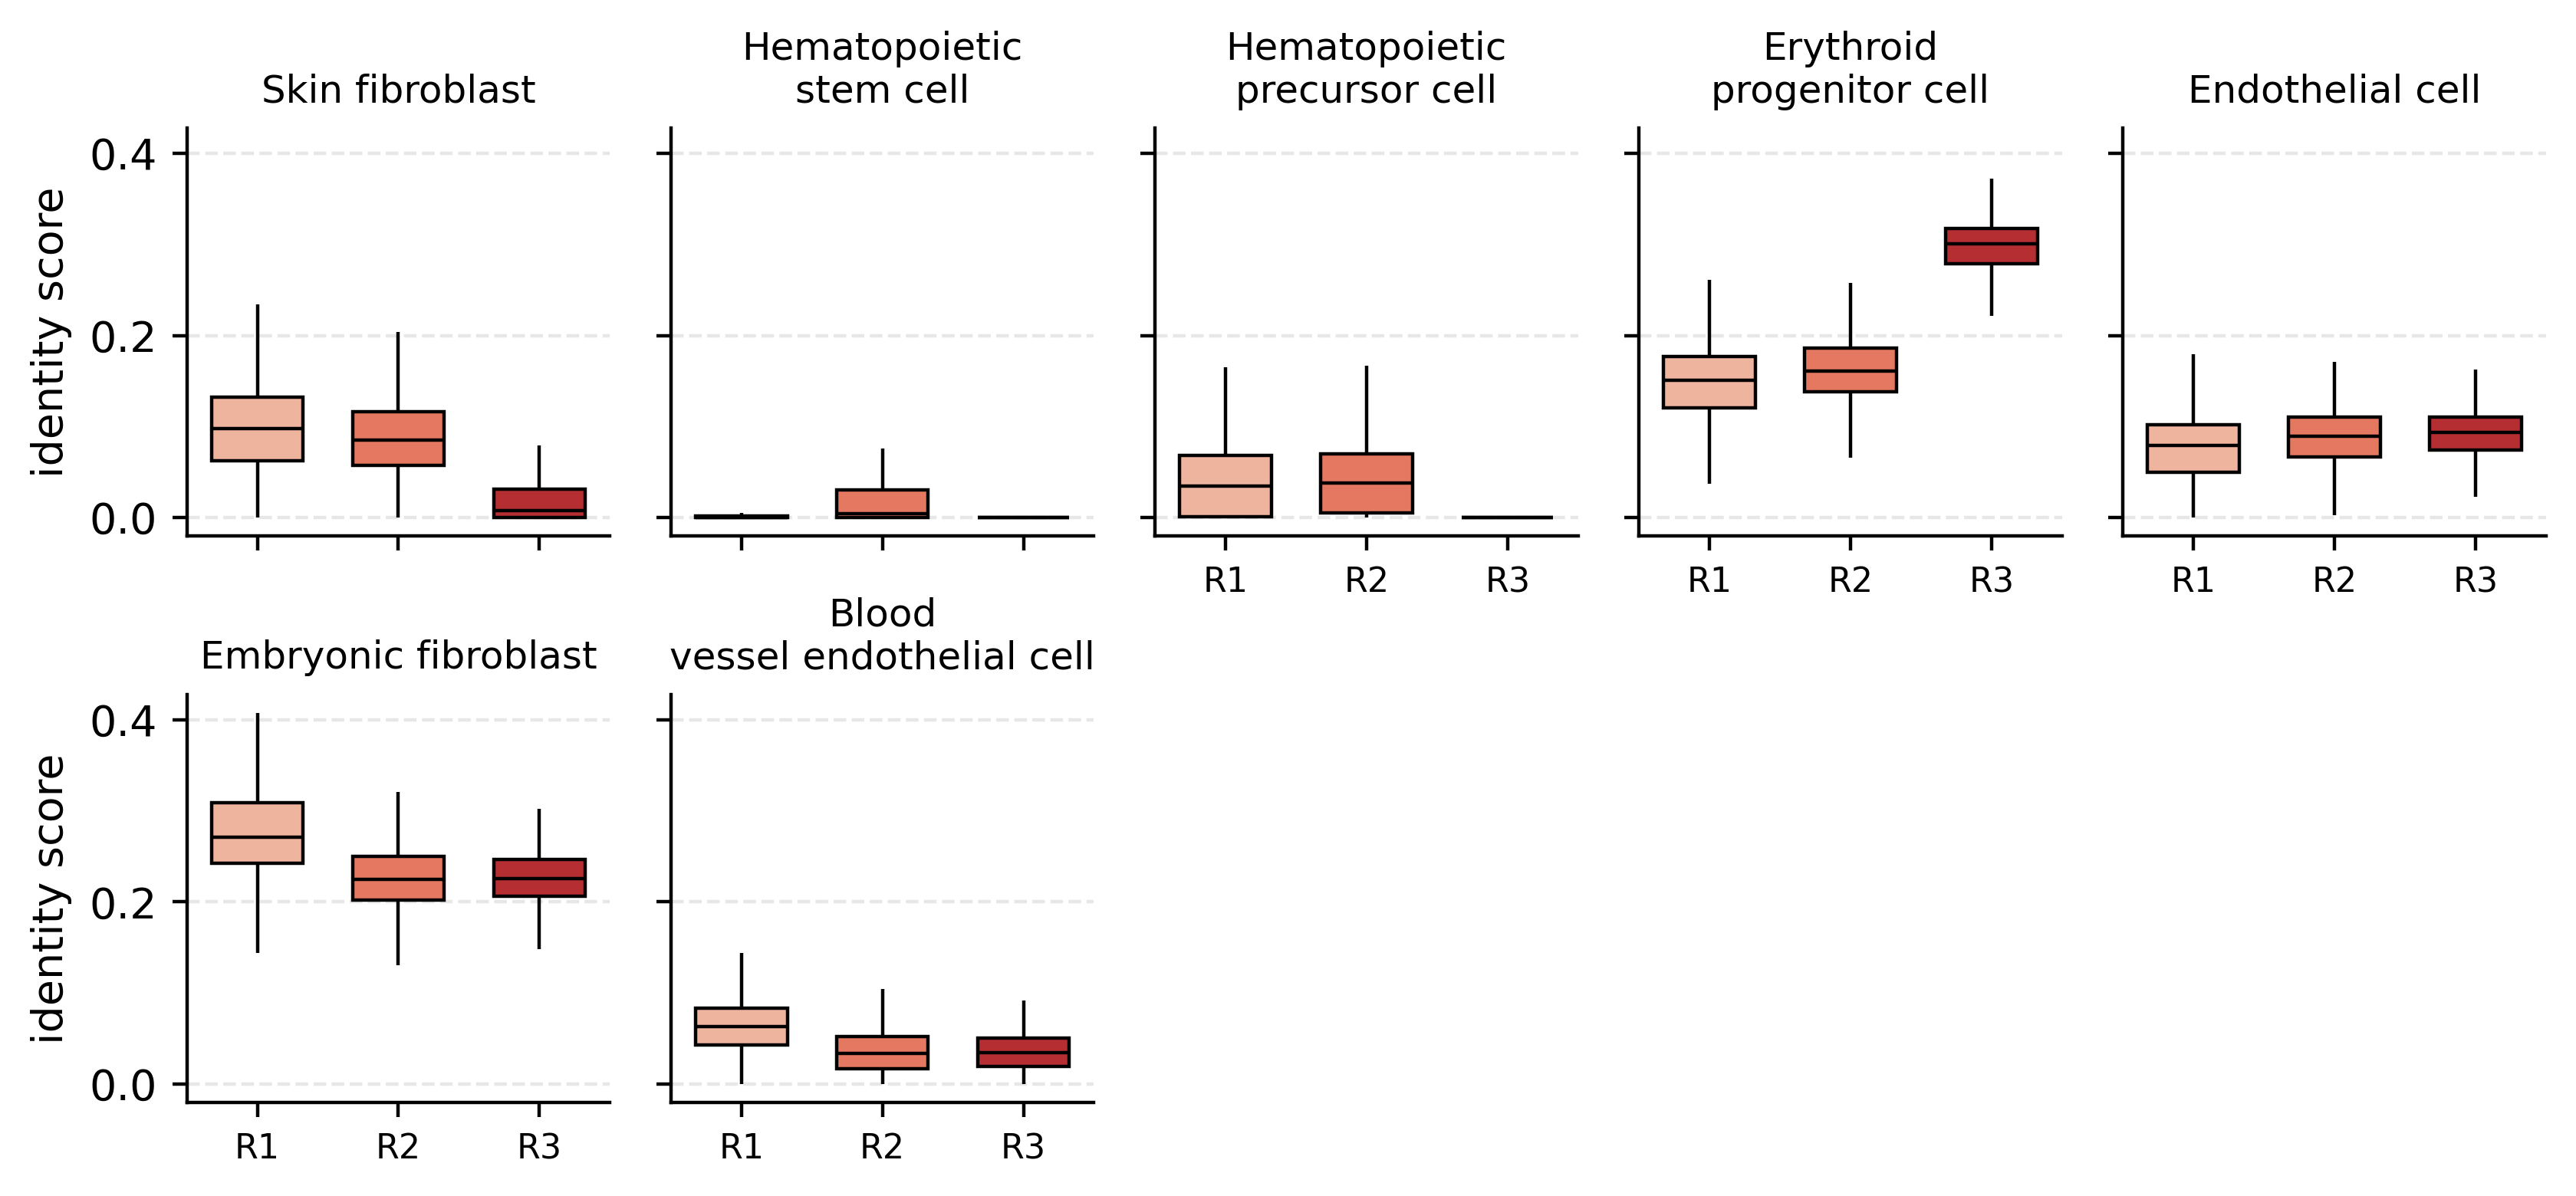

In [17]:
# Copy and melt
df = adata.obs.copy()
frxn_cols = [col for col in df.columns if col.startswith("frxn_")]
df_melted = df.melt(
    id_vars=["cluster"],
    value_vars=frxn_cols,
    var_name="Cell Type",
    value_name="Fraction"
)

#df_melted['Cell Type'] = df_melted['Cell Type'].str.replace('frxn_', '')
df_melted = df_melted.sort_values('Cell Type', ascending=False)

print(df_melted['Cell Type'].unique())

df_melted = df_melted[
    df_melted["Cell Type"].isin([
        "frxn_skin fibroblast",
        "frxn_hematopoietic stem cell",
        "frxn_hematopoietic precursor cell",
        "frxn_fibroadipogenic progenitor cell",
        "frxn_erythroid progenitor cell",
        "frxn_endothelial cell",
        "frxn_embryonic fibroblast",
        "frxn_blood vessel endothelial cell"
    ])
]


g = sns.FacetGrid(
    df_melted,
    col="Cell Type",
    hue="Cell Type",
    col_wrap=5,
    sharey=True,
    height=2,
    aspect=0.85,
)

g.map_dataframe(
    sns.boxplot,
    x="cluster",
    y="Fraction",
    hue="cluster",                # <-- color by cluster
    order=sorted(df["cluster"].unique()),
    palette=cluster_palette,      # <-- custom colors
    width=0.65,
    linecolor="k",
    capprops={"linewidth": 0},
    showfliers=False,
    linewidth=0.8,
    dodge=False                   # <-- keep boxes centered
)

g.set_axis_labels("", "identity score")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
     
    title = ax.get_title()
    title = title.split("frxn_")[1]
    if len(title) > 20:
        title = "\n".join(title.split(maxsplit=1))
    title = title[0].upper() + title[1:]
    ax.set_title(title, fontsize=9)

g.fig.subplots_adjust(wspace=0.2)
plt.rcParams["figure.dpi"] = 400
plt.tight_layout()
plt.show()
